# U.S. Macroeconomic Data Analysis

## Objective
This project analyzes key U.S. macroeconomic indicators using data from the Federal Reserve Economic Data (FRED) API.

The analysis combines:
- Python
- SQLite
- SQL
- pandas
- Matplotlib

## Indicators Analyzed
- Gross Domestic Product (GDP)
- Consumer Price Index (CPI)
- Unemployment Rate
- Federal Funds Rate

## Workflow
FRED API → Python → CSV → SQLite → SQL analysis → Python visualization

In [36]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
conn = sqlite3.connect("../data/raw/macroeconomic_data.db")
print("Connected to database successfully.")

Connected to database successfully.


In [38]:
df = pd.read_sql_query("SELECT * FROM macro_observations", conn)
df.head()

,date,value,series_id
0,1946-01-01,NaN,GDP
1,1946-04-01,NaN,GDP
2,1946-07-01,NaN,GDP
3,1946-10-01,NaN,GDP
4,1947-01-01,243.164,GDP


## Data Validation

The following checks confirm that the macroeconomic dataset loaded correctly from SQLite.

In [39]:
pd.read_sql_query("""
SELECT
    series_id,
    COUNT(*) AS observation_count
FROM macro_observations
GROUP BY series_id
ORDER BY series_id
""", conn)

,series_id,observation_count
0,CPIAUCSL,950
1,FEDFUNDS,860
2,GDP,320
3,UNRATE,938


In [40]:
pd.read_sql_query("""
SELECT
    series_id,
    MIN(date) AS start_date,
    MAX(date) AS end_date
FROM macro_observations
GROUP BY series_id
ORDER BY series_id
""", conn)

,series_id,start_date,end_date
0,CPIAUCSL,1947-01-01,2026-02-01
1,FEDFUNDS,1954-07-01,2026-02-01
2,GDP,1946-01-01,2025-10-01
3,UNRATE,1948-01-01,2026-02-01


In [41]:
def load_series(series_id):
    query = f"""
    SELECT date, value
    FROM macro_observations
    WHERE series_id = '{series_id}'
    ORDER BY date
    """
    return pd.read_sql_query(query, conn, parse_dates=["date"])

In [42]:
gdp = load_series("GDP")
cpi = load_series("CPIAUCSL")
unrate = load_series("UNRATE")
fedfunds = load_series("FEDFUNDS")

print("GDP rows:", len(gdp))
print("CPI rows:", len(cpi))
print("UNRATE rows:", len(unrate))
print("FEDFUNDS rows:", len(fedfunds))

GDP rows: 320
CPI rows: 950
UNRATE rows: 938
FEDFUNDS rows: 860


## Data Validation Interpretation

These validation queries confirm that the macroeconomic dataset was successfully imported into the SQLite database.

Each indicator contains a substantial number of observations and spans several decades, providing sufficient historical coverage for long-term macroeconomic analysis.

The presence of multiple series with different frequencies (monthly for CPI and unemployment, quarterly for GDP) reflects the structure of official economic data released by the Federal Reserve.

## GDP Trend

Gross Domestic Product shows the long-run growth of the U.S. economy over time.

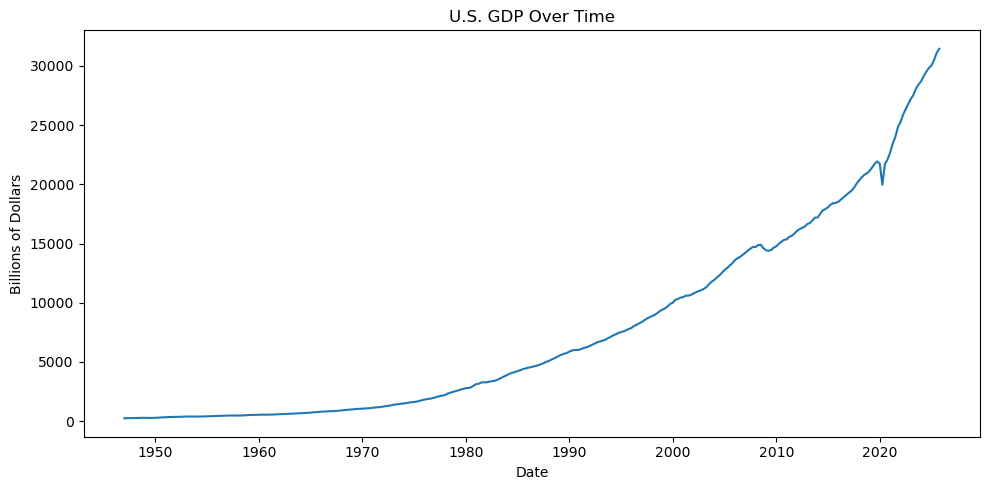

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(gdp["date"], gdp["value"])
plt.title("U.S. GDP Over Time")
plt.xlabel("Date")
plt.ylabel("Billions of Dollars")
plt.tight_layout()
plt.show()

### GDP Trend Interpretation

The GDP series shows a strong long-term upward trend, reflecting sustained economic growth in the United States over the past several decades.

Several important patterns appear:

• Economic output expands steadily over time due to population growth, technological progress, and productivity improvements.

• Temporary slowdowns and declines correspond to major economic crises, such as the 2008 global financial crisis and the sharp contraction during the COVID-19 pandemic.

• The rapid recovery following the pandemic highlights the scale of fiscal stimulus and accommodative monetary policy implemented to stabilize the economy.

• The steep upward slope in recent years also reflects inflation effects, since nominal GDP incorporates both real growth and price increases.

Overall, the GDP trend demonstrates the long-term resilience and expansion of the U.S. economy despite periodic economic shocks.

## CPI Trend

The Consumer Price Index tracks the general price level and is commonly used to study inflation over time.

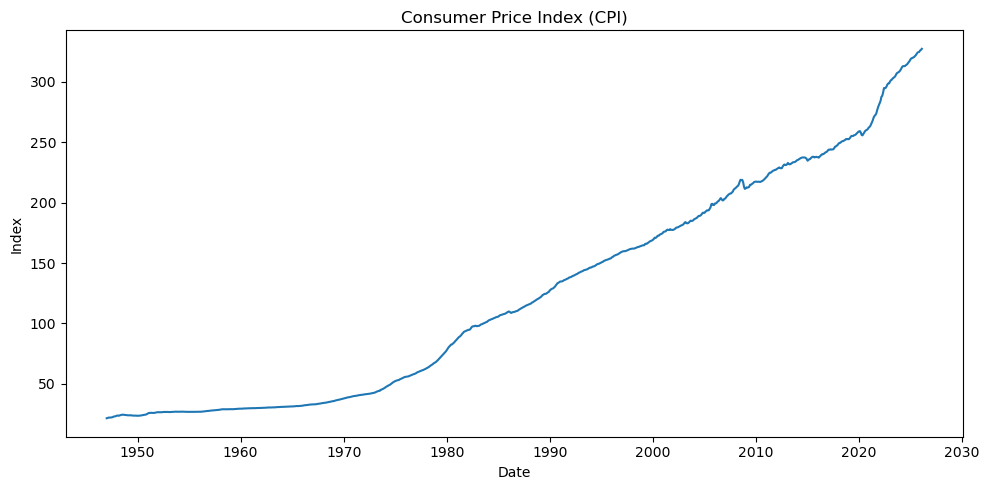

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(cpi["date"], cpi["value"])
plt.title("Consumer Price Index (CPI)")
plt.xlabel("Date")
plt.ylabel("Index")
plt.tight_layout()
plt.show()

## Inflation Trend Interpretation

The Consumer Price Index (CPI) shows a persistent upward trend over time, reflecting long-term inflation in the U.S. economy.

Several key patterns are visible:

• Inflation accelerates during certain macroeconomic periods such as the 1970s oil shocks.  
• After the 1980s, inflation becomes more stable following aggressive monetary policy by the Federal Reserve.  
• The most recent data shows a sharp increase in CPI during the post-pandemic period, reflecting supply chain disruptions and expansionary fiscal and monetary policy.

Overall, the CPI series illustrates the long-run erosion of purchasing power and the importance of monetary policy in stabilizing inflation.

## Unemployment Rate

The unemployment rate reflects cyclical changes in the labor market and tends to rise during recessions.

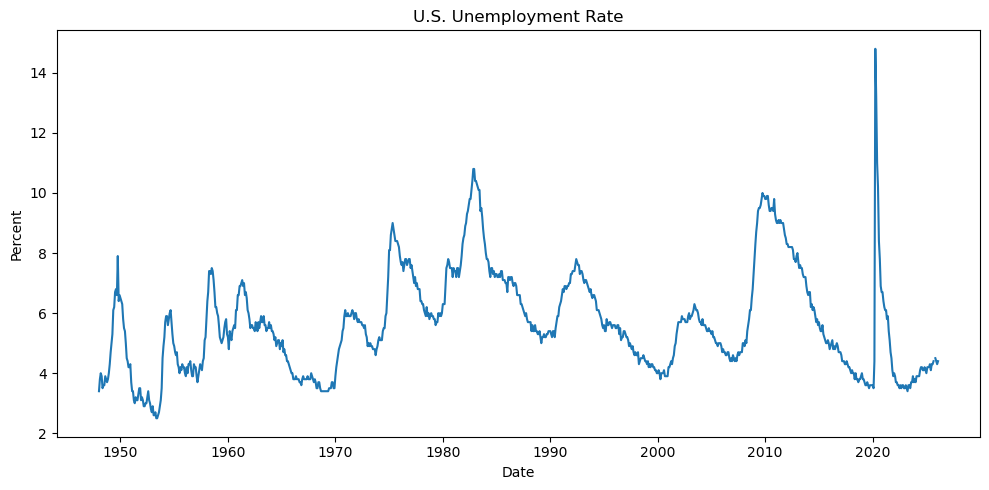

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(unrate["date"], unrate["value"])
plt.title("U.S. Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()

## Labor Market Interpretation

The unemployment rate fluctuates strongly over the business cycle.

Key observations include:

• Major spikes occur during recessions such as the early 1980s recession, the 2008 financial crisis, and the COVID-19 pandemic.  
• Between recessions, unemployment typically declines gradually during economic expansions.  
• The most recent data suggests the labor market has stabilized around historically moderate levels.

These patterns illustrate the cyclical nature of labor markets and the relationship between economic growth and employment.

## Federal Funds Rate

The federal funds rate reflects the stance of U.S. monetary policy and changes across tightening and easing cycles.

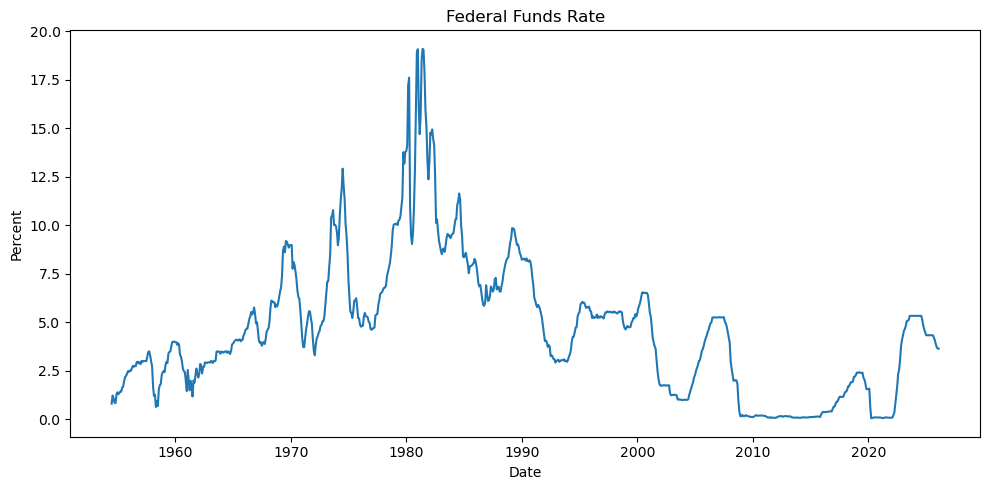

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(fedfunds["date"], fedfunds["value"])
plt.title("Federal Funds Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()

## Monetary Policy Interpretation

The Federal Funds Rate reflects the stance of U.S. monetary policy.

Several structural shifts are visible:

• High interest rates in the late 1970s and early 1980s correspond to the Federal Reserve's effort to combat high inflation.  
• Rates declined steadily during the long disinflation period from the 1980s through the 2000s.  
• Extremely low rates occurred during major economic crises such as the 2008 financial crisis and the COVID-19 pandemic.  
• The recent rise in rates reflects tightening monetary policy to control inflation.

The Federal Funds Rate therefore serves as a key policy tool used by the Federal Reserve to influence economic activity and inflation.

## Average Unemployment by Decade

This query summarizes labor market conditions across decades by calculating the average unemployment rate.

In [47]:
unemployment_by_decade = pd.read_sql_query("""
SELECT
    (CAST(strftime('%Y', date) AS INTEGER) / 10) * 10 AS decade,
    ROUND(AVG(value), 2) AS avg_unemployment_rate
FROM macro_observations
WHERE series_id = 'UNRATE'
GROUP BY decade
ORDER BY decade
""", conn)

unemployment_by_decade

,decade,avg_unemployment_rate
0,1940,4.90
1,1950,4.51
2,1960,4.78
3,1970,6.22
4,1980,7.27
5,1990,5.76
6,2000,5.54
7,2010,6.22
8,2020,4.83


### Unemployment by Decade Interpretation

Average unemployment rates varied significantly across decades, reflecting major macroeconomic cycles and policy environments.

• The 1950s and 1960s show relatively low unemployment, reflecting strong postwar economic expansion and rapid industrial growth.

• The 1970s mark a shift toward higher unemployment, coinciding with oil shocks and the emergence of stagflation, where inflation and unemployment rose simultaneously.

• The 1980s recorded the highest average unemployment in the dataset. This period reflects the severe recessions triggered by the Federal Reserve's aggressive interest rate hikes aimed at controlling inflation.

• Unemployment gradually declined during the 1990s and 2000s as economic expansion and technological growth supported job creation.

• The 2010s experienced moderate unemployment following recovery from the 2008 financial crisis.

• The 2020s show relatively lower average unemployment despite the COVID-19 shock, reflecting rapid fiscal and monetary policy responses and strong labor market recovery.

Overall, the data highlights how labor market conditions are closely tied to economic cycles and policy responses.

## GDP Growth Rate

The following query calculates quarter-over-quarter GDP growth using a SQL window function.

In [48]:
gdp_growth = pd.read_sql_query("""
WITH gdp AS (
    SELECT
        date,
        value,
        LAG(value, 1) OVER (ORDER BY date) AS prev_gdp
    FROM macro_observations
    WHERE series_id = 'GDP'
)
SELECT
    date,
    value,
    prev_gdp,
    ROUND(((value - prev_gdp) / prev_gdp) * 100, 2) AS gdp_growth_pct
FROM gdp
WHERE prev_gdp IS NOT NULL
ORDER BY date
""", conn, parse_dates=["date"])

gdp_growth.head()

,date,value,prev_gdp,gdp_growth_pct
0,1947-04-01,245.968,243.164,1.15
1,1947-07-01,249.585,245.968,1.47
2,1947-10-01,259.745,249.585,4.07
3,1948-01-01,265.742,259.745,2.31
4,1948-04-01,272.567,265.742,2.57


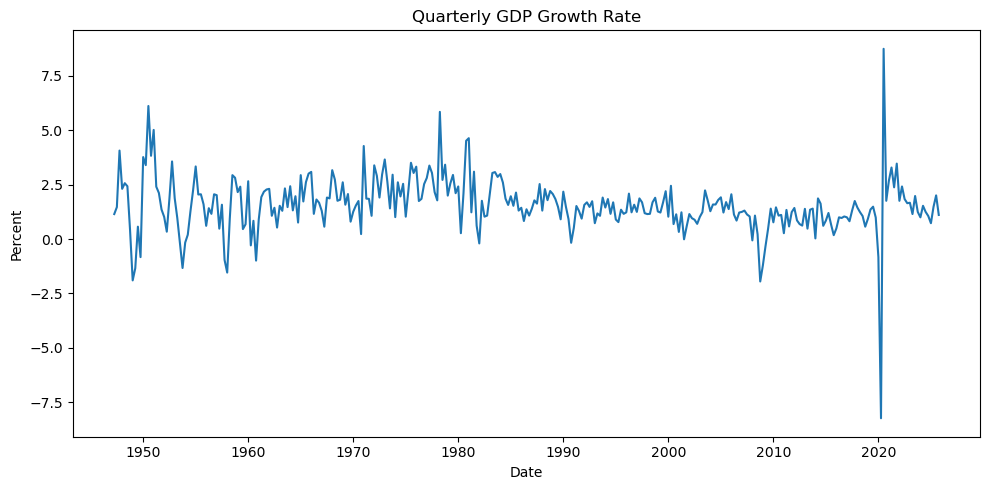

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(gdp_growth["date"], gdp_growth["gdp_growth_pct"])
plt.title("Quarterly GDP Growth Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()

## Economic Growth Interpretation

Gross Domestic Product (GDP) represents the total economic output of the United States.

The long-run trend shows steady economic expansion over time, reflecting population growth, technological innovation, and productivity improvements.

However, short-term fluctuations are visible during major economic disruptions such as:

• The 2008 global financial crisis  
• The COVID-19 pandemic

Despite these shocks, the overall upward trajectory highlights the resilience of the U.S. economy over the long run.

## Macroeconomic Relationships

Macroeconomic indicators are deeply interconnected.

• Rising inflation often leads the Federal Reserve to increase interest rates in order to slow economic activity.

• Higher interest rates can reduce investment and spending, which may eventually increase unemployment.

• Economic expansions typically coincide with falling unemployment and rising GDP.

Understanding these relationships is essential for analyzing economic cycles and evaluating policy decisions.

## Key Insights

This analysis of U.S. macroeconomic indicators highlights several important relationships.

• Long-term economic growth is evident in the sustained expansion of GDP.

• Inflation dynamics, captured by CPI, show how price levels evolve and how policy interventions stabilize inflation over time.

• Labor market conditions fluctuate with business cycles, as seen in unemployment patterns across decades.

• Monetary policy, represented by the Federal Funds Rate, plays a central role in managing inflation and stabilizing economic activity.

Together, these indicators illustrate the interaction between economic growth, labor markets, inflation, and monetary policy in shaping the U.S. macroeconomic environment.

## Tools Used

Python  
pandas  
Matplotlib  
SQLite  
FRED API

In [50]:
conn.close()
print("Database connection closed.")

Database connection closed.
